### **Manual BackPropagation of a MLP**

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# New code

# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
# Neural Network Definition of Layers, Weights, Biases

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation

# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer

# Linear layer 2
logits = h @ W2 + b2 # output layer

# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3351, grad_fn=<NegBackward0>)

#### **Manual BackPropagation Exercises**

##### **Exercise 1 - Backpropagate through the whole thing manually**

Backpropagating through exactly all of the variables as they are defined in the forward pass above, one by one

In the below we will begin differentiating the loss with respect to each component of the neural network starting from `logprobs` to `emb`

**1. Finding** $\frac{\partial \text{loss}}{\partial \text{logprobs}}$

#
```python
loss = -logprobs[range(n), Yb].mean() 
     = For each row i in logprobs, pick out logprobs[i, Yb[i]] 
       the log-probability assigned to the correct label — then average over all n rows and negate.
```
#

$\text{loss} = -\frac{1}{n}\sum_{i=0}^{n-1} \text{logprobs}_{i,\,y_i}$  
$\quad\quad= \text{sum of each log probability at index } (i, y_i)\text{ (probability of predicting the correct label), divided by } n\text{, and negated}$
#

$\frac{\partial}{\partial \text{logprobs}_{i,y_i}}\left(-\frac{1}{n}\,\text{logprobs}_{i,y_i}\right) = -\frac{1}{n}$ (differentiating the expression by each correct log probability)
#

Since there are other unused probabilities which show the probability of predicting a letter that is not the label - they have a derivative of 0 and we can ignore them since they are not part of the expression
#

$∴ \frac{\partial \text{loss}}{\partial \text{logprobs}}$ is a 32x27 tensor of values $-\frac{1}{n} = -\frac{1}{32}$ at the 32 positions corresponding to the correct labels and 0's elsewhere since the derivative of a scalar wrt to a tensor always has the same shape as that tensor

**Note: Derivative of a scalar wrt to a matrix involves differentating the scalar wrt to every individual element in the matrix independently and arranging the results back into a matrix of the same shape**

In [10]:
dlogprobs = torch.zeros_like(logprobs) # this creates a tensor of the same dimension
dlogprobs[range(n), Yb] = -1.0/n # indexing the corresponding indexes to -1/n 
                                 # essentially making logprobs a 0 tensor and then replacing the correct probabilities indexes with the derivative
dlogprobs
# cmp('logprobs', dlogprobs, logprobs) # function that compares what pytorch calculates to our exact gradient 

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -0.0312,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0312,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.0312,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

**2. Finding $\frac{\partial \text{loss}}{\partial \text{probs}}$**

```python
logprobs = probs.log()
```

We can apply the chain rule here using the intermediate $\frac{\partial \text{logprobs}}{\partial \text{probs}}$

$\frac{\partial \text{loss}}{\partial \text{probs}} = \frac{\partial \text{loss}}{\partial \text{logprobs}} × \frac{\partial \text{logprobs}}{\partial \text{probs}}$ (element-wise product of the 2 derivative matrices)

#
$logprobs = ln(probs)$ 



$\frac{\partial \text{logprobs}_{i,j}}{\partial \text{probs}_{i,j}} = \frac{1}{\text{probs}_{i,j}}$ 

Elementwise differentiation occurs — each value in the matrix has an independent effect on the loss so we want to the ROC of the loss wrt to each individual value - e.g. each logprobs value comes from one input value probs in the matrix so we only need elementwise differentation

The result is also element wise division a 32x27 matrix of 1.0's is divided by corresponding probs


#
$∴ \frac{\partial \text{loss}}{\partial \text{probs}} = \frac{\partial \text{loss}}{\partial \text{logprobs}} × \frac{1}{probs}$
#
**Note: When we apply `.log()`, we take the natural log of each individual element in `probs` and return the resultant matrix - we do not "log the entire matrix as one" and as such when we perform differentation of $\frac{\partial \text{logprobs}}{\partial \text{probs}}$ - we are performing element-wise differentation**

**Element-wise differentation occurs if the forwards operation is `*`, `+`, `-`, `.log()`, `.exp()`, etc. Non-element-wise differentation occurs when actual matrix multiplication `@` occurs - it requires the sum of all element-wise differentiation paths (multivariable chain rule) rather than straight forward differentation**

In [11]:
dprobs = dlogprobs * 1.0/probs 
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


**3. Finding** $\frac{\partial \text{loss}}{\partial \text{counts-sum-inv}}$

```python
probs = counts * counts_sum_inv
```
$\frac{\partial \text{loss}}{\partial \text{counts-sum-inv}} = \frac{\partial \text{loss}}{\partial \text{probs}} × \frac{\partial \text{probs}}{\partial \text{counts-sum-inv}}$

$probs = counts × \text{counts-sum-inv}$ 

$\frac{\partial \text{probs}}{\partial \text{counts-sum-inv}} = counts$

$\frac{\partial \text{lyeoss}}{\partial \text{counts-sum-inv}} = \frac{\partial \text{loss}}{\partial \text{probs}} × counts$

**Note: We have to be careful here because the shape of `dprobs` is (32,27) and the shape of `counts_sum_inv` is (32,1) so broadcasting will need to occur for element-wise operations**

**Intuitive Dimension Matching Explanation**

Since we are finding $\frac{\partial \text{loss}}{\partial \text{counts-sum-inv}}$ - we are differentiating a scalar wrt to a tensor so the dimension of the output should be equivalent to the dimension of the tensor which is (32,1) - due to broadcasting, the dimension of the output is (32,27) so we need to collapse each column into a single column forming a (32,1) matrix, which we can only do by summing each row

**Mathematical Explanation**

Since `counts_sum_inv` is used across all 27 entires of `probs` in its row when multiplied with counts - that one `counts_sum_inv` value participates in 27 separate multiplications 

Its total effect on the loss is hence the sum of its individual effects through each of these 27 entries - so the gradient must sum across that broadcast dimension


Hence there are 2 scenarios for element-wise operation 
1. Same shape - Normal element-wise differenttation

2. Different shape - Intermediate broadcasting before element-wise differentiation
- Bonus: If matrix multiplication `@` occurs in forward pass => matrix differentiation 


In [12]:
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # 32x27 output so must be summed to make 32x1
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


**4.1. Finding** $\frac{\partial \text{loss}}{\partial \text{counts}}$

```python
probs = counts * counts_sum_inv
```

$\frac{\partial \text{loss}}{\partial \text{counts}} = \frac{\partial \text{loss}}{\partial \text{probs}} × \frac{\partial \text{probs}}{\partial \text{counts}}$

$\frac{\partial \text{probs}}{\partial \text{counts}} = \text{counts-sum-inv}$

$\frac{\partial \text{loss}}{\partial \text{counts}} = \frac{\partial \text{loss}}{\partial \text{probs}} × \text{counts-sum-inv}$

**Note: As we can see in the equations, counts is involved on the RHS in 2 equations**
1. `probs = counts * counts_sum_inv`
2. `counts_sum = counts.sum(1, keepdims=True)`

**As such we need to add these 2 gradeints to get the total ROC of `loss` wrt to `counts`** 

In [13]:
dcounts = dprobs * counts_sum_inv

**5. Finding** $\frac{\partial \text{loss}}{\partial \text{counts-sum}}$

```python
counts_sum_inv = counts_sum**-1
```

$\frac{\partial \text{loss}}{\partial \text{counts-sum}} = \frac{\partial \text{loss}}{\partial \text{counts-sum-inv}} × \frac{\partial \text{counts-sum-inv}}{\partial \text{counts-sum}}$

$\frac{\partial \text{counts-sum-inv}}{\partial \text{counts-sum}} = \frac{-1}{countssum^2}$

In [14]:
dcounts_sum = dcounts_sum_inv * (-counts_sum**-2)
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


**4.2. Finding** $\frac{\partial \text{loss}}{\partial \text{counts}}$

```python
counts_sum = counts.sum(1, keepdims=True)`
```

$\frac{\partial \text{loss}}{\partial \text{counts}} = \frac{\partial \text{loss}}{\partial \text{counts-sum}} × \frac{\partial \text{counts-sum}}{\partial \text{counts}}$

$\frac{\partial \text{counts-sum}}{\partial \text{counts}}$ = 1 (when an individual element of the sum is changed, the sum changes proportionately => 1)

$\frac{\partial \text{loss}}{\partial \text{counts}} = \frac{\partial \text{loss}}{\partial \text{counts-sum}} × 1$

But since the shape of counts is (32, 27) this needs to be broadcasted from (32,1)

In [15]:
# add on the second branch of dcounts since it appears twice (multivariable chain rule)
dcounts += torch.ones_like(counts) * dcounts_sum # broadcasted to (32,27)
cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


**6. Finding** $\frac{\partial \text{loss}}{\partial \text{norm-logits}}$

```python
counts = norm_logits.exp()
```

$\frac{\partial \text{loss}}{\partial \text{norm-logits}} = \frac{\partial \text{loss}}{\partial \text{counts}} × \frac{\partial \text{counts}}{\partial \text{norm-logits}}$

$\frac{\partial \text{counts}}{\partial \text{norm-logits}} = e^{normlogits}$

$\frac{\partial \text{loss}}{\partial \text{norm-logits}} = \frac{\partial \text{loss}}{\partial \text{counts}} × e^{normlogits}$

In [16]:
dnorm_logits = dcounts * norm_logits.exp() # same as * counts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


**7.1. Finding** $\frac{\partial \text{loss}}{\partial \text{logits}}$

```python
norm_logits = logits - logit_maxes
```

$\frac{\partial \text{loss}}{\partial \text{logits}} = \frac{\partial \text{loss}}{\partial \text{norm-logits}} × \frac{\partial \text{norm-logits}}{\partial \text{logits}}$

$\frac{\partial \text{norm-logits}}{\partial \text{logits}} = 1$

$\frac{\partial \text{loss}}{\partial \text{logits}} = \frac{\partial \text{loss}}{\partial \text{norm-logits}} × 1$


`logits` is involved on the RHS twice so we must add the other path `logit_maxes = logits.max(1, keepdim=True).values`

In [17]:
dlogits = dnorm_logits.clone() # clone it so that they are not connected by reference

**8. Finding** $\frac{\partial \text{loss}}{\partial \text{logits-maxes}}$
```python
norm_logits = logits - logit_maxes
```

$\frac{\partial \text{loss}}{\partial \text{logit-maxes}} = \frac{\partial \text{loss}}{\partial \text{norm-logits}} × \frac{\partial \text{norm-logits}}{\partial \text{logit-maxes}}$

$\frac{\partial \text{norm-logits}}{\partial \text{logit-maxes}}$ = -1

$\frac{\partial \text{loss}}{\partial \text{logit-maxes}} = \frac{\partial \text{loss}}{\partial \text{norm-logits}} × -1$

`norm_logits` has a shape of (32,27) but `logit_maxes` has a shape of (32,1) and to ensure that the shape is (32,1) we must sum along rows, collapsing dimension 1 (columns)

In [18]:
dlogit_maxes = -dnorm_logits.sum(dim=1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


**7.2. Finding** $\frac{\partial \text{loss}}{\partial \text{logits}}$

```python
logit_maxes = logits.max(1, keepdim=True).values
```

$\frac{\partial \text{loss}}{\partial \text{logits}} = \frac{\partial \text{loss}}{\partial \text{logit-maxes}} × \frac{\partial \text{logit-maxes}}{\partial \text{logits}}$

$\frac{\partial \text{logit-maxes}_{i}}{\partial \text{logits}_{i, j}}$ = 1 (if max of the row) or 0 (otherwise) 

Reads the partial derivative of the i-th entry of `logit_maxes` with respect to the (i, j)-th entry of `logits`

Should output a matrix with all zeros, except for the maxes which are represented as 1's at the corresponding indexes (one-hot encoded)

#
```python
logits.max(dim=1, keepdim=False, num_classes = logits.shape[1]).indices
```
Recreates `logit_maxes` but calls the `.indices` attribute to return the indexes of the max values rather than the max values so we can one-hot encode them 

`keepdim=False` since we only need 1 dimension for one-hot encoding since it adds an extra dimension to make it 2d which is what we need

`num_classes = logits.shape[1]` to guarantee that the number of classes remains consistently 27 - if there is a class that is never the maximum, `F.one_hot` does not know there are 27 classes and will return 26

In [19]:
# the second matrix output should be a matrix with all zeros 
dlogits += dlogit_maxes * F.one_hot(logits.max(dim=1, keepdim=False).indices, num_classes=logits.shape[1])
cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


**9. Finding** $\frac{\partial \text{loss}}{\partial \text{h}}$
```python
logits = h @ W2 + b2
```

$\frac{\partial \text{loss}}{\partial \text{h}} = \frac{\partial \text{loss}}{\partial \text{logits}} × \frac{\partial \text{logits}}{\partial \text{h}}$

We can clearly see that logits involves a matrix multiplication of `h` with `W2` and as such involves true matrix differentiation unlike the previous element-wise differentiations - Forward pass operation is matrix multiplication (output dependent on multiple inputs) => differentiation of a matrix multiplication (not element-wise)


**Fundamental Rule of Matrix Differentiation**

$L = \begin{bmatrix} f(x) & g(x) \\ h(x) & i(x) \end{bmatrix}
\quad \Rightarrow \quad
\frac{dL}{dx} = \begin{bmatrix} f'(x) & g'(x) \\ h'(x) & i'(x) \end{bmatrix}$

$\text{logits} = h \,@\, W2 + b2$

To find the derivative of logits with respect to h we can express the matrix as multiple elements of linear equations

$\begin{bmatrix} \text{logits}_{11} & \text{logits}_{12} \\ \text{logits}_{21} & \text{logits}_{22} \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} \\ h_{21} & h_{22} \end{bmatrix} \begin{bmatrix} W2_{11} & W2_{12} \\ W2_{21} & W2_{22} \end{bmatrix} + \begin{bmatrix} b2_1 & b2_2 \\ b2_1 & b2_2 \end{bmatrix}$

$\Rightarrow \text{logits}_{11} = h_{11}W2_{11} + h_{12}W2_{21} + b2_1$

$\Rightarrow \text{logits}_{12} = h_{11}W2_{12} + h_{12}W2_{22} + b2_2$

$\Rightarrow \text{logits}_{21} = h_{21}W2_{11} + h_{22}W2_{21} + b2_1$

$\Rightarrow \text{logits}_{22} = h_{21}W2_{12} + h_{22}W2_{22} + b2_2$

#
---

**Differentiating loss with respect to each entry of $h$:**

**Note: We have $\dfrac{\partial \text{loss}}{\partial \text{logits}}$ from the previous backpropagation and can apply chain-rule per element when performing matrix differentiation**


$\dfrac{\partial \text{loss}}{\partial h_{11}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times \dfrac{\partial \text{logits}_{11}}{\partial h_{11}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times \dfrac{\partial \text{logits}_{12}}{\partial h_{11}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times W2_{11} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times W2_{12}$

$\dfrac{\partial \text{loss}}{\partial h_{12}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times \dfrac{\partial \text{logits}_{11}}{\partial h_{12}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times \dfrac{\partial \text{logits}_{12}}{\partial h_{12}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times W2_{21} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times W2_{22}$

$\dfrac{\partial \text{loss}}{\partial h_{21}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times \dfrac{\partial \text{logits}_{21}}{\partial h_{21}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times \dfrac{\partial \text{logits}_{22}}{\partial h_{21}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times W2_{11} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times W2_{12}$

$\dfrac{\partial \text{loss}}{\partial h_{22}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times \dfrac{\partial \text{logits}_{21}}{\partial h_{22}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times \dfrac{\partial \text{logits}_{22}}{\partial h_{22}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times W2_{21} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times W2_{22}$

#
---

**Assembling back into matrix form:**

$\dfrac{\partial \text{loss}}{\partial h} = \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial h_{11}} & \dfrac{\partial \text{loss}}{\partial h_{12}} \\[6pt] \dfrac{\partial \text{loss}}{\partial h_{21}} & \dfrac{\partial \text{loss}}{\partial h_{22}} \end{bmatrix} = \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} & \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \\[6pt] \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} & \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \end{bmatrix} \begin{bmatrix} W2_{11} & W2_{21} \\ W2_{12} & W2_{22} \end{bmatrix}$

$\therefore \quad \dfrac{\partial \text{loss}}{\partial h} = \dfrac{\partial \text{loss}}{\partial \text{logits}} \;@\; W2^{T}$   

where W2 is transposed

In [20]:
dh = dlogits @ W2.T
cmp('h', dh, h)

h               | exact: True  | approximate: True  | maxdiff: 0.0


**Trick**
- Simple trick to remember the formula is to refer back to the conventions of matrix multiplication
- `dlogits` is always involved (32,27)
- Some matrix multiplication is involved to return a matrix with the shape equal to h's shape (32, 64) as differentiating a scalar by a tensor always produces a tensor of the same shape
- (32, 27) x (27, 64) = (32, 64) so we must multiply by a matrix of shape (27, 64) = transposed matrix of W2 (shape of (64, 27) originally)

**10. Finding** $\frac{\partial \text{loss}}{\partial \text{W2}}$

```python
logits = h @ W2 + b2
```

$\frac{\partial \text{loss}}{\partial \text{h}} = \frac{\partial \text{loss}}{\partial \text{logits}} × \frac{\partial \text{logits}}{\partial \text{W2}}$

**Differentiating loss with respect to each entry of $W2$:**

Note $W2_{11}$ appears in both $\text{logits}_{11}$ (row 1) and $\text{logits}_{21}$ (row 2) — it's reused across all rows of the batch, so we sum over both paths.

$\dfrac{\partial \text{loss}}{\partial W2_{11}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times \dfrac{\partial \text{logits}_{11}}{\partial W2_{11}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times \dfrac{\partial \text{logits}_{21}}{\partial W2_{11}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times h_{11} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times h_{21}$

$\dfrac{\partial \text{loss}}{\partial W2_{12}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times \dfrac{\partial \text{logits}_{12}}{\partial W2_{12}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times \dfrac{\partial \text{logits}_{22}}{\partial W2_{12}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times h_{11} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times h_{21}$

$\dfrac{\partial \text{loss}}{\partial W2_{21}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times \dfrac{\partial \text{logits}_{11}}{\partial W2_{21}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times \dfrac{\partial \text{logits}_{21}}{\partial W2_{21}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times h_{12} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times h_{22}$

$\dfrac{\partial \text{loss}}{\partial W2_{22}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times \dfrac{\partial \text{logits}_{12}}{\partial W2_{22}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times \dfrac{\partial \text{logits}_{22}}{\partial W2_{22}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times h_{12} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times h_{22}$

---

**Assembling back into matrix form:**

$\dfrac{\partial \text{loss}}{\partial W2} = \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial W2_{11}} & \dfrac{\partial \text{loss}}{\partial W2_{12}} \\[6pt] \dfrac{\partial \text{loss}}{\partial W2_{21}} & \dfrac{\partial \text{loss}}{\partial W2_{22}} \end{bmatrix} = \begin{bmatrix} h_{11} & h_{21} \\ h_{12} & h_{22} \end{bmatrix} \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} & \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \\[6pt] \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} & \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \end{bmatrix}$

$\therefore \quad \dfrac{\partial \text{loss}}{\partial W2} = h^{T} \;@\; \dfrac{\partial \text{loss}}{\partial \text{logits}}$

where h is transposed

In [21]:
dW2 = h.T @ dlogits 
cmp('W2', dW2, W2)

W2              | exact: True  | approximate: True  | maxdiff: 0.0


**Trick**
- `dW2` = some matrix multiplication involving `dlogits` such that the shape = shape of `W2` (64,27)
- `dlogits` = (32, 27) => (64,27) = (64, 32) x (32, 27) => we require a matrix of shape (64, 32) to be multiplied to `dlogits`
- `h` = (32, 64) => $ h^{T}$ = (64,32) 

**11. Finding** $\frac{\partial \text{loss}}{\partial \text{b2}}$

```python
logits = h @ W2 + b2
```

$\frac{\partial \text{loss}}{\partial \text{h}} = \frac{\partial \text{loss}}{\partial \text{logits}} × \frac{\partial \text{logits}}{\partial \text{b2}}$

**Differentiating loss with respect to each entry of $b2$:**

Note $b2_1$ is broadcast across every row of `logits` (it appears in $\text{logits}_{11}$ AND $\text{logits}_{21}$ — column 1 of every row), so we sum over both rows. Same for $b2_2$ in column 2.

$\dfrac{\partial \text{loss}}{\partial b2_1} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times \dfrac{\partial \text{logits}_{11}}{\partial b2_1} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times \dfrac{\partial \text{logits}_{21}}{\partial b2_1} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} \times 1 + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} \times 1$

$\dfrac{\partial \text{loss}}{\partial b2_2} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times \dfrac{\partial \text{logits}_{12}}{\partial b2_2} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times \dfrac{\partial \text{logits}_{22}}{\partial b2_2} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} \times 1 + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \times 1$

---

**Simplifying (local derivative is always 1, since $b2$ is added directly):**

$\dfrac{\partial \text{loss}}{\partial b2_1} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}}$

$\dfrac{\partial \text{loss}}{\partial b2_2} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}}$

---

**Assembling back into vector form — this is summing down each column (the batch/row dimension):**

$\dfrac{\partial \text{loss}}{\partial b2} = \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial b2_1} & \dfrac{\partial \text{loss}}{\partial b2_2} \end{bmatrix} = \begin{bmatrix} \dfrac{\partial \text{loss}}{\partial \text{logits}_{11}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{21}} & \dfrac{\partial \text{loss}}{\partial \text{logits}_{12}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{22}} \end{bmatrix}$

$\therefore \quad \dfrac{\partial \text{loss}}{\partial b2} = \dfrac{\partial \text{loss}}{\partial \text{logits}}.\text{sum}(\text{dim}=0)$

where $\text{logits} = h \,@\, W2 + b2$

In [22]:
db2 = dlogits.sum(dim=0)
cmp('b2', db2, b2)

b2              | exact: True  | approximate: True  | maxdiff: 0.0


**Trick**
- Output must be same shape as b2 = (27) and must involve dlogits (32,27)
- We want to collapse dlogits to 1 dimension (27) => collapse dim=0 (collapse rows into a single row) by summing along columns

**12. Finding** $\frac{\partial \text{loss}}{\partial \text{hpreact}}$

```python
h = torch.tanh(hpreact)
```
#

$\frac{\partial \text{loss}}{\partial \text{hpreact}} = \frac{\partial \text{loss}}{\partial \text{h}} × \frac{\partial \text{h}}{\partial \text{hpreact}}$

#
$h = tanh(hpreact)$

$\frac{\partial \text{h}}{\partial \text{hpreact}} = 1 - \tanh^2(hpreact)$

#
$\frac{\partial \text{loss}}{\partial \text{hpreact}} = \frac{\partial \text{loss}}{\partial \text{h}} ×  1 - \tanh^2(hpreact)$

In [23]:
dhpreact = dh * (1.0 - (hpreact.tanh())**2)
cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: True  | approximate: True  | maxdiff: 0.0


**13. Finding** $\frac{\partial \text{loss}}{\partial \text{bngain}}$

```python
hpreact = bngain * bnraw + bnbias
```
#
$\frac{\partial \text{loss}}{\partial \text{bngain}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × \frac{\partial \text{hpreact}}{\partial \text{bngain}}$

$\frac{\partial \text{hpreact}}{\partial \text{bngain}} = bnraw$

$\frac{\partial \text{loss}}{\partial \text{bngain}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × bnraw$


In [24]:
dbngain = torch.sum(dhpreact * bnraw, dim=0, keepdim=True) 
cmp('bngain', dbngain, bngain)

bngain          | exact: True  | approximate: True  | maxdiff: 0.0


**14. Finding** $\frac{\partial \text{loss}}{\partial \text{bnbias}}$

```python
hpreact = bngain * bnraw + bnbias
```
#
$\frac{\partial \text{loss}}{\partial \text{bnbias}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × \frac{\partial \text{hpreact}}{\partial \text{bnbias}}$

$\frac{\partial \text{hpreact}}{\partial \text{bnbias}} = 1$

$\frac{\partial \text{loss}}{\partial \text{bnbias}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × 1$

In [25]:
dbnbias = torch.sum(dhpreact.clone(),dim=0,keepdim=True)
cmp('bnbias', dbnbias, bnbias)

bnbias          | exact: True  | approximate: True  | maxdiff: 0.0


**15. Finding** $\frac{\partial \text{loss}}{\partial \text{bnraw}}$

```python
hpreact = bngain * bnraw + bnbias
```
#
$\frac{\partial \text{loss}}{\partial \text{bnraw}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × \frac{\partial \text{hpreact}}{\partial \text{bnraw}}$

$\frac{\partial \text{hpreact}}{\partial \text{bnraw}} = bngain$

$\frac{\partial \text{loss}}{\partial \text{bnraw}} = \frac{\partial \text{loss}}{\partial \text{hpreact}} × bngain$

In [26]:
dbnraw = dhpreact * bngain
cmp('bnraw', dbnraw, bnraw)

bnraw           | exact: True  | approximate: True  | maxdiff: 0.0


**16. Finding** $\frac{\partial \text{loss}}{\partial \text{bnvar-inv}}$

```python
bnraw = bndiff * bnvar_inv
```
#
$\frac{\partial \text{loss}}{\partial \text{bnvar-inv}} = \frac{\partial \text{loss}}{\partial \text{bnraw}} × \frac{\partial \text{bnraw}}{\partial \text{bnvar-inv}}$

$\frac{\partial \text{bnraw}}{\partial \text{bnvar-inv}} = bndiff$

$\frac{\partial \text{loss}}{\partial \text{bnvar-inv}} = \frac{\partial \text{loss}}{\partial \text{bnraw}} × bndiff$



In [27]:
dbnvar_inv = torch.sum(dbnraw * bndiff, dim=0, keepdim=True)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0


**17.1. Finding** $\frac{\partial \text{loss}}{\partial \text{bndiff}}$

```python
bnraw = bndiff * bnvar_inv
```
#
$\frac{\partial \text{loss}}{\partial \text{bndiff}} = \frac{\partial \text{loss}}{\partial \text{bnraw}} × \frac{\partial \text{bnraw}}{\partial \text{bndiff}}$

$\frac{\partial \text{bnraw}}{\partial \text{bndiff}}$ = bnvar_inv

$\frac{\partial \text{loss}}{\partial \text{bndiff}} = \frac{\partial \text{loss}}{\partial \text{bnraw}}$ × bnvar_inv

In [28]:
dbndiff = dbnraw * bnvar_inv

**18. Finding** $\frac{\partial \text{loss}}{\partial \text{bnvar}}$

```python
bnvar_inv = (bnvar + 1e-5)**-0.5
```
#
$\frac{\partial \text{loss}}{\partial \text{bnvar}} = \frac{\partial \text{loss}}{\partial \text{bnvar-inv}} × \frac{\partial \text{bnvar-inv}}{\partial \text{bnvar}}$

$\frac{\partial \text{bnvar-inv}}{\partial \text{bnvar}} = -0.5(bnvar + 0.00001)^{-1.5}$

$\frac{\partial \text{loss}}{\partial \text{bnvar}} = \frac{\partial \text{loss}}{\partial \text{bnvar-inv}} × -0.5(bnvar + 0.00001)^{-1.5}$

In [29]:
dbnvar = dbnvar_inv * -0.5 * (bnvar + 1e-5)**(-1.5)
cmp('bnvar', dbnvar, bnvar)

bnvar           | exact: True  | approximate: True  | maxdiff: 0.0


**19. Finding** $\frac{\partial \text{loss}}{\partial \text{bndiff2}}$

```python
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
```
#
$\frac{\partial \text{loss}}{\partial \text{bndiff2}} = \frac{\partial \text{loss}}{\partial \text{bnvar}} × \frac{\partial \text{bnvar}}{\partial \text{bndiff2}}$

$\frac{\partial \text{bnvar}}{\partial \text{bndiff2}} = \frac{1}{n-1}$

$\frac{\partial \text{loss}}{\partial \text{bndiff2}} = \frac{\partial \text{loss}}{\partial \text{bnvar}} × \frac{1}{n-1} $

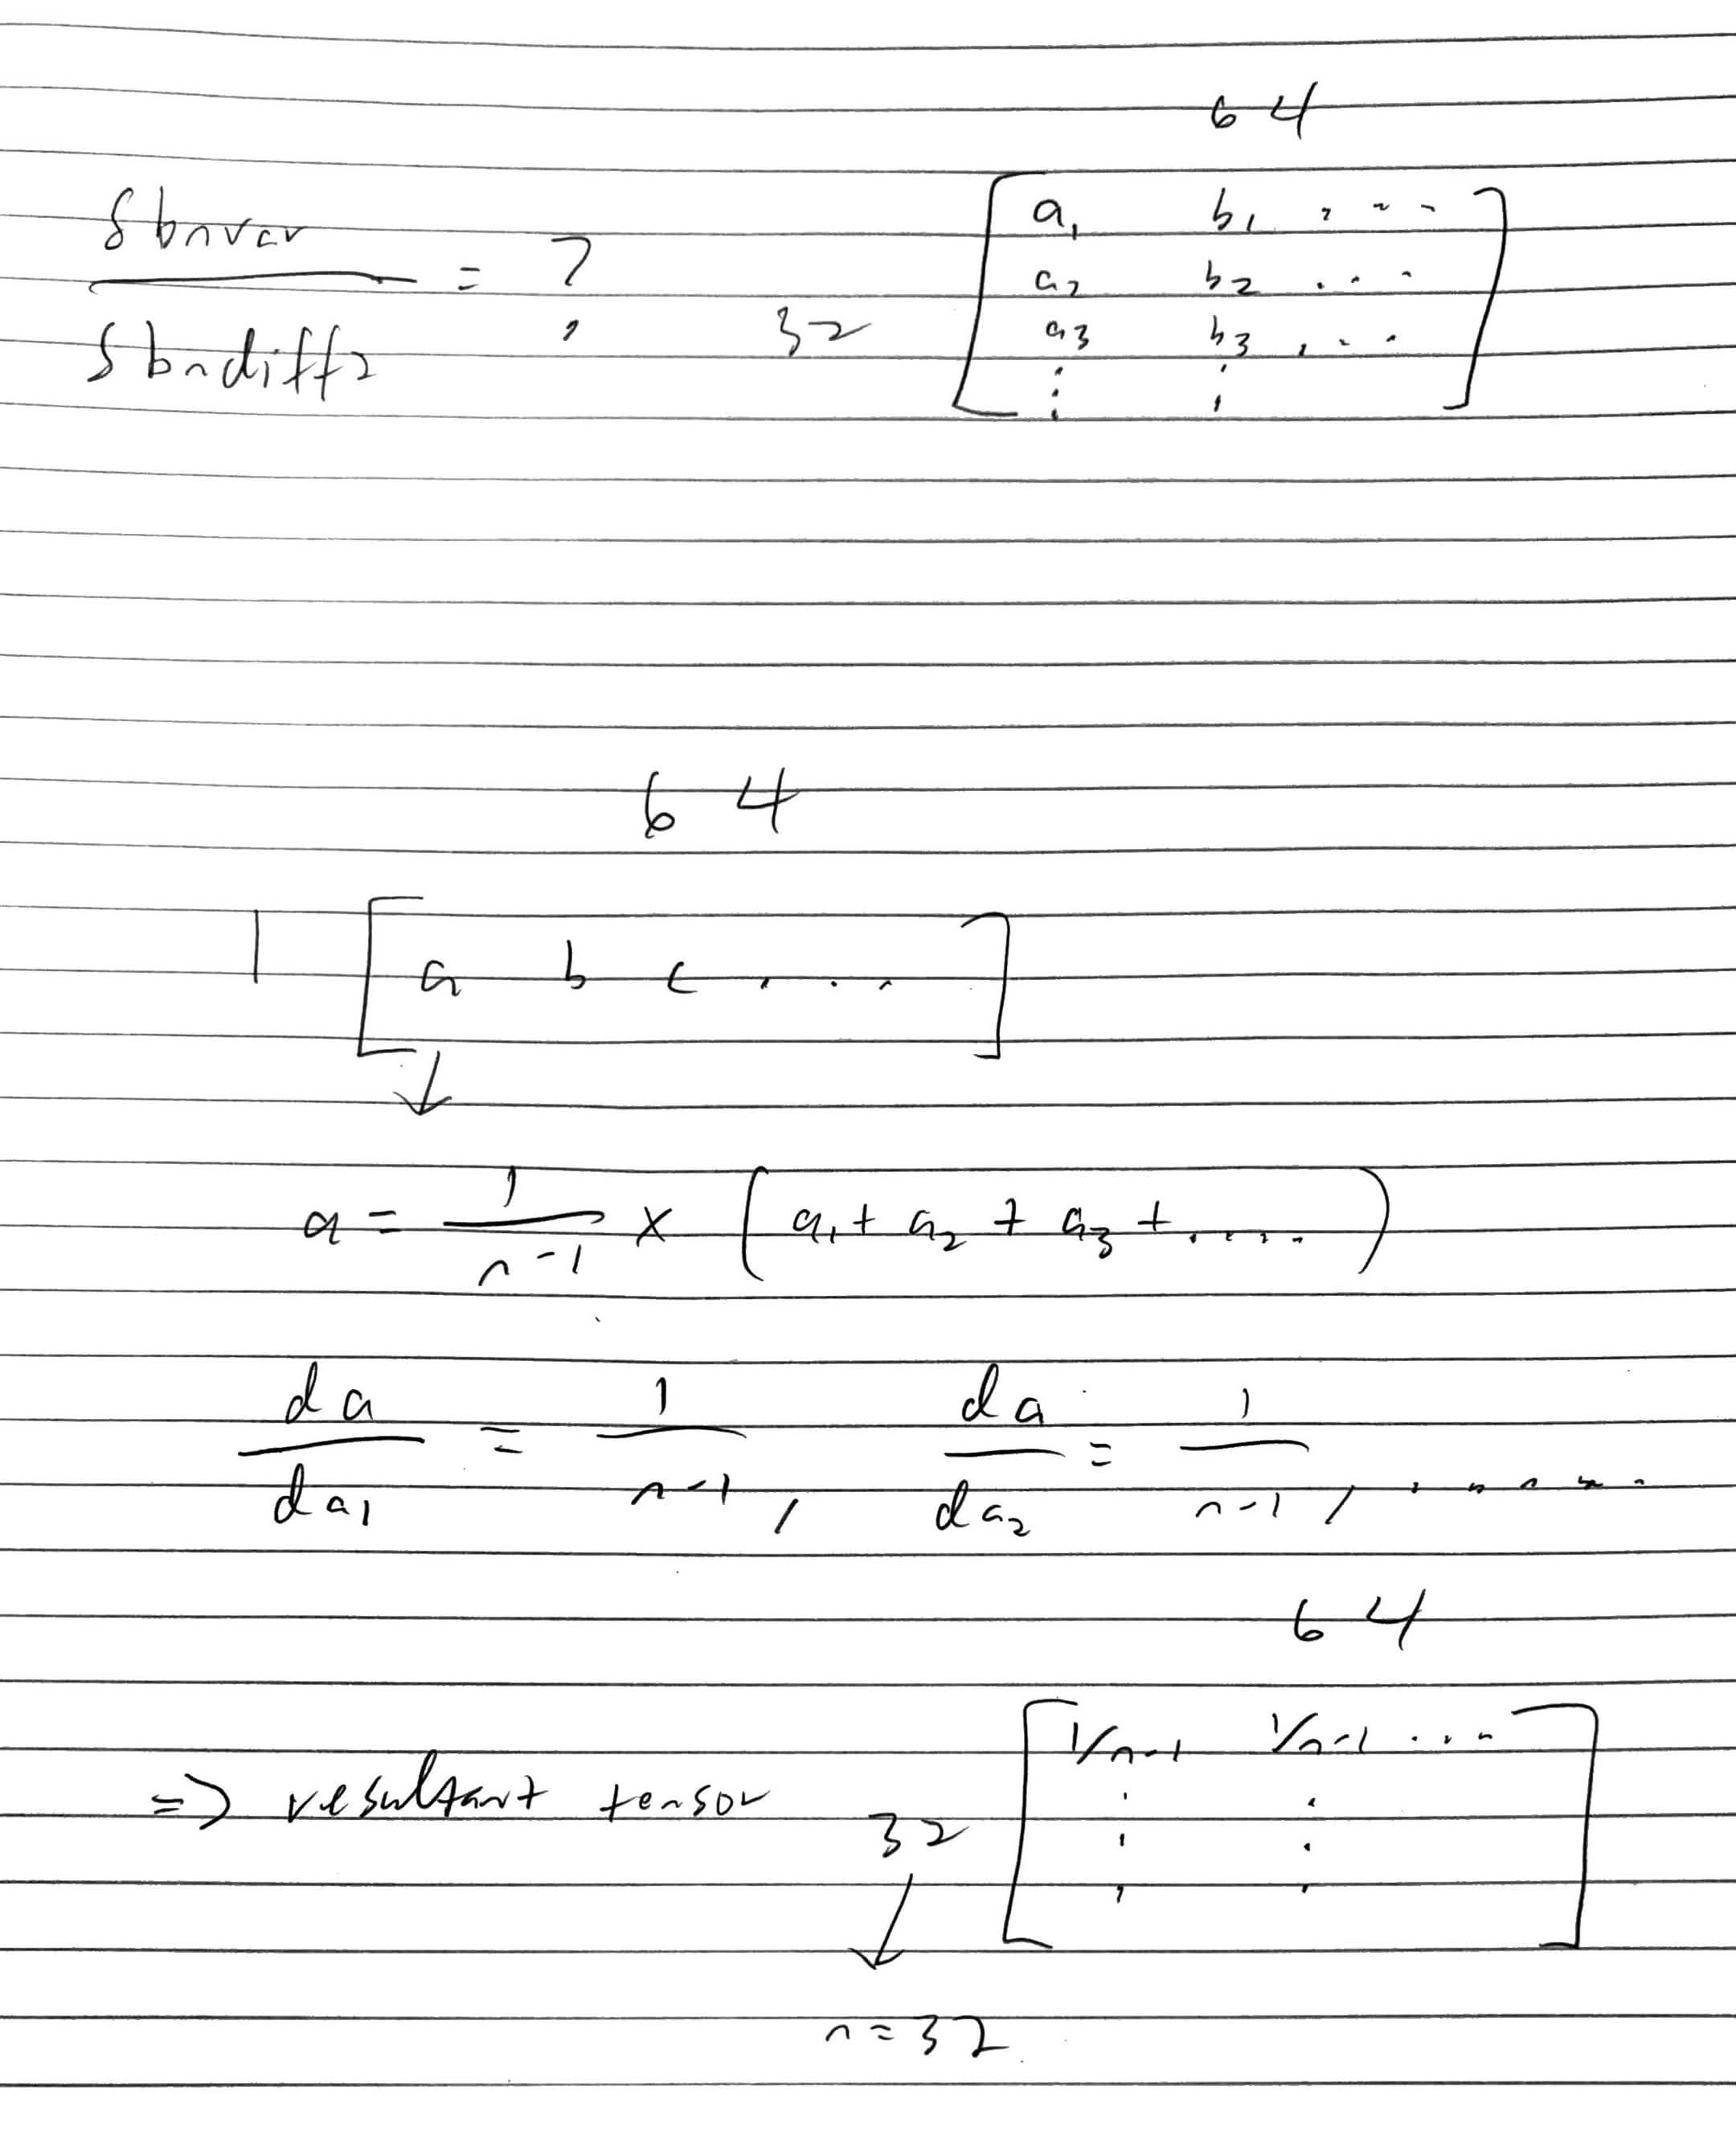

**Note: Key to differentiating sums and trickier functions is to break it up into element-wise differentiation (since the forward pass involves an element-wise operation) and form the tensor after differentiating each element**

In [30]:
dbndiff2 = dbnvar * torch.ones(32,64) * (1/(n-1))
cmp('bndiff2', dbndiff2, bndiff2)

bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0


**17.2. Finding** $\frac{\partial \text{loss}}{\partial \text{bndiff}}$

```python
bndiff2 = bndiff**2
```
#
$\frac{\partial \text{loss}}{\partial \text{bndiff}} = \frac{\partial \text{loss}}{\partial \text{bndiff2}} × \frac{\partial \text{bndiff2}}{\partial \text{bndiff}}$

$\frac{\partial \text{bndiff2}}{\partial \text{bndiff}} = 2 × bndiff$

$\frac{\partial \text{loss}}{\partial \text{bndiff}} = \frac{\partial \text{loss}}{\partial \text{bndiff2}} × 2 × bndiff$

In [31]:
dbndiff += dbndiff2 * 2 * bndiff
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: True  | approximate: True  | maxdiff: 0.0


**18. Finding** $\frac{\partial \text{loss}}{\partial \text{bnmeani}}$

```python
bndiff = hprebn - bnmeani
```
#
$\frac{\partial \text{loss}}{\partial \text{bnmeani}} = \frac{\partial \text{loss}}{\partial \text{bndiff}} × \frac{\partial \text{bndiff}}{\partial \text{bmeani}}$

$\frac{\partial \text{bndiff}}{\partial \text{bnmeani}} = -1$

$\frac{\partial \text{loss}}{\partial \text{bnmeani}} = \frac{\partial \text{loss}}{\partial \text{bndiff}} × -1$

In [32]:
dbnmeani = torch.sum(dbndiff * -1, dim=0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)

bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0


**19.1. Finding** $\frac{\partial \text{loss}}{\partial \text{hprebn}}$

```python
bndiff = hprebn - bnmeani
```
#
$\frac{\partial \text{loss}}{\partial \text{hprebn}} = \frac{\partial \text{loss}}{\partial \text{bndiff}} × \frac{\partial \text{bndiff}}{\partial \text{hprebn}}$

$\frac{\partial \text{bndiff}}{\partial \text{hprebn}} = 1$

$\frac{\partial \text{loss}}{\partial \text{hprebn}} = \frac{\partial \text{loss}}{\partial \text{bndiff}} × 1$

In [33]:
dhprebn = dbndiff.clone()

**19.2. Finding** $\frac{\partial \text{loss}}{\partial \text{hprebn}}$

```python
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
```
#
$\frac{\partial \text{loss}}{\partial \text{hprebn}} = \frac{\partial \text{loss}}{\partial \text{bnmeani}} × \frac{\partial \text{bnmeani}}{\partial \text{hprebn}}$

$\frac{\partial \text{bnmeani}}{\partial \text{hprebn}} = \frac{1}{n}$

$\frac{\partial \text{loss}}{\partial \text{hprebn}} = \frac{\partial \text{loss}}{\partial \text{dbnmeani}} × \frac{1}{n}$

In [34]:
dhprebn += dbnmeani * (1/n)
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


**20. Finding** $\frac{\partial \text{loss}}{\partial \text{embcat}}$

```python
hprebn = embcat @ W1 + b1
```
#
$\frac{\partial \text{loss}}{\partial \text{embcat}} = \frac{\partial \text{loss}}{\partial \text{hprebn}} × \frac{\partial \text{hprebn}}{\partial \text{embcat}}$

$\frac{\partial \text{hprebn}}{\partial \text{embcat}} = \frac{\partial \text{loss}}{\partial \text{hprebn}}$  @  $W1^T$

In [35]:
dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

embcat          | exact: True  | approximate: True  | maxdiff: 0.0


**21. Finding** $\frac{\partial \text{loss}}{\partial \text{W1}}$

```python
hprebn = embcat @ W1 + b1
```
#
$\frac{\partial \text{loss}}{\partial \text{W1}} = \frac{\partial \text{loss}}{\partial \text{hprebn}} × \frac{\partial \text{hprebn}}{\partial \text{W1}}$

$\frac{\partial \text{loss}}{\partial \text{W1}} = embcat^{T}$ @  $\frac{\partial \text{loss}}{\partial \text{hprebn}}$  

In [36]:
dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

W1              | exact: True  | approximate: True  | maxdiff: 0.0


**22. Finding** $\frac{\partial \text{loss}}{\partial \text{b1}}$

```python
hprebn = embcat @ W1 + b1
```
#
$\frac{\partial \text{loss}}{\partial \text{b1}} = \frac{\partial \text{loss}}{\partial \text{hprebn}} × \frac{\partial \text{hprebn}}{\partial \text{b1}}$

$\frac{\partial \text{loss}}{\partial \text{b1}} = \frac{\partial \text{loss}}{\partial \text{hprebn}}.sum(dim=0)$

In [37]:
db1 = dhprebn.sum(dim=0, keepdims=True)
cmp('b1', db1, b1)

b1              | exact: True  | approximate: True  | maxdiff: 0.0


**23. Finding** $\frac{\partial \text{loss}}{\partial \text{emb}}$

```python
embcat = emb.view(emb.shape[0], -1)
```
#
$\frac{\partial \text{loss}}{\partial \text{emb}} = \frac{\partial \text{loss}}{\partial \text{embcat}} × \frac{\partial \text{embcat}}{\partial \text{emb}}$

$\frac{\partial \text{loss}}{\partial \text{emb}} = \frac{\partial \text{loss}}{\partial \text{embcat}}$

Inuititvely, `.view()` just restructures the tensor to have different dimensions, so the rate at which the restructured tensor changes is equivalent to the rate at which the original tensor changes since the values are identical in both tensors

In [38]:
demb = dembcat.view(embcat.shape[0], 3, 10)
cmp('emb', demb, emb)

emb             | exact: True  | approximate: True  | maxdiff: 0.0


**24. Finding** $\frac{\partial \text{loss}}{\partial \text{C}}$

```python
emb = C[Xb] = F.one_hot(Xb, num_classes=27).float() @ C.float()
```

$\frac{\partial \text{loss}}{\partial \text{emb}} = \frac{\partial \text{loss}}{\partial \text{embcat}}$

The key intuition is to recognise that indexing can be represented as matrix multiplication paired with one-hot encoding 

Using the dervied linear matrix equation - it is now simply matrix differentiation

Applying the Formula:

$ d = a$ @ $b + c \quad\rightarrow\quad\dfrac{\partial \text{loss}}{\partial b} = a^{T} \;@\; \dfrac{\partial \text{loss}}{\partial \text{d}}$

$\frac{\partial \text{loss}}{\partial \text{C}} = onehot^{T} \:@\: \frac{\partial \text{loss}}{\partial \text{emb}}$

In [39]:
# emb = C[Xb] = indexing = one_hot(Xb) @ C
dC = F.one_hot(Xb, num_classes=27).float().view(-1,27).T @ demb.view(-1, 10)
cmp('C', dC, C)

C               | exact: True  | approximate: True  | maxdiff: 0.0


Matrix Shape Intuition:
- Intuitively, we know that the shape of the output must equal the shape of `C` (27, 10)

- `demb` must be involved and has a shape of (32, 3, 10) - we can reshape this to (96, 10) and have ( _ , _ ) × (96, 10) = (27, 10)

- `.view()` reshaping is required so that the output is 2 dimensions just like `C`

- `F.one_hot(Xb, num_classes=27)` has a shape of (32, 3, 27) which we can reshape to (96, 27) to get the 27 and then transpose to (27, 96) as per the formula 

- (27, 96) × (96, 10) gives the required shape of (27, 10)

In [40]:
C.shape, demb.shape,  F.one_hot(Xb, num_classes=27).shape

(torch.Size([27, 10]), torch.Size([32, 3, 10]), torch.Size([32, 3, 27]))

#
#

##### **Exercise 2 - Backpropagate through Cross_Entropy in one go**

- The backpropagation we did previously involved backpropagating through every part of `cross_entropy` 

- We can simplify this by backpropagating through `cross_entropy` directly without having to split into parts before backpropagating through each part of the function

In [41]:
# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.335083484649658 diff: 0.0


##### **Fused Derivation Proof:** $\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}$

```python
logit_maxes = logits.max(dim=1, keepdim=True).values
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(dim=1, keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()
```

`logits` feeds into the loss through **two paths**:
- **Path 1:** $\text{logits} \rightarrow \text{norm\_logits} \rightarrow \text{counts} \rightarrow \text{probs} \rightarrow \text{logprobs} \rightarrow \text{loss}$
- **Path 2:** $\text{logits} \rightarrow \text{logit\_maxes} \rightarrow \text{norm\_logits} \rightarrow \text{counts} \rightarrow \text{probs} \rightarrow \text{logprobs} \rightarrow \text{loss}$

By the **sum over paths** rule:

$\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}^{\text{path 1}} + \dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}^{\text{path 2}}$

**Note: (i, j) indicate the derivative is for the loss with respect to a single cell of the `logits` matrix rather than the entire matrix - the collection of these individual derivatives form the `dlogits` matrix**


**Step 1:** $\dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,j}}$

$\text{loss} = -\frac{1}{n}\sum\limits_{i=0}^{n-1} \text{logprobs}_{i,\,y_i}$ — only the correct label index $y_i$ is summed per row - sums all the log probabilities of predicting the correct label 

#

$\dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,j}} = \begin{cases} -\dfrac{1}{n} & j = y_i \\[6pt] 0 & \text{otherwise} \end{cases}$

$y_i$ denotes the index of the correct class for the i-th example. The gradient is non-zero only at the log-probability corresponding to the true class, i.e. when the class index $j$ equals $y_i$ since loss only sums the log-probabilities for the correct label and ignore the other labels

---

**Step 2:** $\dfrac{\partial \text{loss}}{\partial \text{probs}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,j}} × \dfrac{\partial \text{logprobs}_{i,j}}{\partial \text{probs}_{i,j}}$

$\text{logprobs} = \ln(\text{probs})$ — elementwise
#
$\rightarrow\dfrac{\partial \text{logprobs}_{i,j}}{\partial \text{probs}_{i,j}} = \dfrac{1}{\text{probs}_{i,j}}$ (differentiating individual elements of `logprobs` wrt to the corresponding element in `probs` with the same index)

$\dfrac{\partial \text{loss}}{\partial \text{probs}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,j}} \times \dfrac{1}{\text{probs}_{i,j}} = \begin{cases} -\dfrac{1}{n} × \dfrac{1}{probs_{i, j}} & j = y_i \\[6pt] 0 & \text{otherwise}\quad\text{(Since anything multiplied by 0 is 0, incorrect-class entries' remain 0)}\end{cases}$

---

**Step 3**: $\dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,j}} \cdot \dfrac{\partial \text{logprobs}_{i,j}}{\partial \text{probs}_{i,j}} \cdot \dfrac{\partial \text{probs}_{i,j}}{\partial \text{counts}_{i,j}} + \sum\limits_{k=0}^{V-1} \dfrac{\partial \text{loss}}{\partial \text{logprobs}_{i,k}} \cdot \dfrac{\partial \text{logprobs}_{i,k}}{\partial \text{probs}_{i,k}} \cdot \dfrac{\partial \text{probs}_{i,k}}{\partial \text{counts\_sum\_inv}_{i, 0}} \cdot \dfrac{\partial \text{counts\_sum\_inv}_{i, 0}}{\partial \text{counts\_sum}_{i, 0}} \cdot \dfrac{\partial \text{counts\_sum}_{i, 0}}{\partial \text{counts}_{i,j}}$

**Note: Since the sum of logprobs is from k = 0 to V-1, independent of i and j - this means the sum includes all paths and therefore the non-zero gradient probabilities meaning the otherwise is not simply 0 like previously**

`counts` has **two paths** to the loss:
- **Path A:** $\text{counts} \rightarrow \text{probs} \rightarrow \text{logprobs} \rightarrow \text{loss}$
- **Path B:** $\text{counts} \rightarrow \text{counts\_sum} \rightarrow \text{counts\_sum\_inv} \rightarrow \text{probs} \rightarrow \text{logprobs} \rightarrow \text{loss}$

**Path A** — $\text{probs}_{i,j} = \text{counts}_{i,j} \times \text{counts\_sum\_inv}_{i, 0}\quad$ (`counts_sum_inv` only has dimensions (N, 1) so `0` there is only 1 column)

$\dfrac{\partial \text{probs}_{i,j}}{\partial \text{counts}_{i,j}}  = \text{counts\_sum\_inv}_{i, 0}$

$\dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}}^{A} = \dfrac{\partial \text{loss}}{\partial \text{probs}_{i,j}} \times \text{counts\_sum\_inv}_{i,0} = \begin{cases} -\dfrac{1}{n} × \dfrac{1}{probs_{i, j}} \times \text{counts\_sum\_inv}_{i} & j = y_i \\[6pt] 0 & \text{otherwise} \end{cases}$

Since $\text{probs}_{i,y_i} = \text{counts}_{i,y_i} \times \text{counts\_sum\_inv}_{i, 0}$ , we have $\dfrac{\text{counts\_sum\_inv}_{i, 0}}{\text{probs}_{i,y_i}} = \dfrac{1}{\text{counts}_{i,y_i}}:$

$\dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}}^{A} = \begin{cases} -\dfrac{1}{n}\times\dfrac{1}{counts_{i,y_i}} & j = y_i \\[6pt] 0 & \text{otherwise} \end{cases}$

#
**Path B** — first find $\dfrac{\partial \text{loss}}{\partial \text{counts\_sum\_inv}_{i, 0}}$. Since `counts_sum_inv` broadcasts across all 27 columns, sum over paths:

$\text{probs}_{i,j} = \text{counts}_{i,j} \times \text{counts\_sum\_inv}_{i, 0}\quad$
#

$\dfrac{\partial \text{probs}_{i,j}}{\partial \text{counts\_sum\_inv}_{i, 0}}  = \text{counts}_{i,j}$

$\dfrac{\partial \text{loss}}{\partial \text{counts\_sum\_inv}_{i, 0}} = \sum\limits_{j=0}^{V-1} \dfrac{\partial \text{loss}}{\partial \text{probs}_{i,j}} \times\dfrac{\partial \text{probs}_{i,j}}{\partial \text{counts\_sum\_inv}_{i, 0}} = \sum\limits_{j=0}^{V-1} \dfrac{\partial \text{loss}}{\partial \text{probs}_{i,j}} \times \text{counts}_{i,j}\quad$ (V = vocab_size - 27 characters)

**The intermediate j is arbitrary, it can be any value for the same derivative since i is what is relevant and as such we require the summation of all 27 possible j values for each possible character (summing all possible paths to the derivative)**

**Note: The key to dealing with matrix differentiation and broadcasting is to keep track of the shape of the matrices - if the shapes do not match for chain rule then consider the effect of broadcasting and sum all possible paths of broadcasting** 

Like in the above, there can be multiple j's which are arbitrary due to the effect of broadcasting so sum all derivative paths - broadcasting (summing derivatives) will be obvious when there is a dimension absent or 1 dimension only has 1 e.g. the above is (i, 0) indicating columns has only 1 while the other has 27 indicating that broadcasting is required

#
Only $j = y_i$ is nonzero so we can simplify the summation is essentially 1 value where $j = y_i$ plus the result when j is anything else which is 0: 

$\dfrac{\partial \text{loss}}{\partial \text{counts\_sum\_inv}_{i, 0}} = -\dfrac{1}{n} × \dfrac{1}{probs_{i, y_i}} \times \text{counts}_{i,y_i} = -\dfrac{1}{n} \times \dfrac{\text{counts}_{i,y_i}}{\text{probs}_{i,y_i}} = -\dfrac{\text{counts\_sum}_{i, 0}}{n}$

(since $\dfrac{\text{counts}_{i,y_i}}{\text{probs}_{i,y_i}} = \dfrac{1}{\text{counts\_sum\_inv}_{i, 0}} = \text{counts\_sum}_{i, 0}$ and inv = inverse)

Now chain through $\text{counts\_sum\_inv}_{i, 0} = \text{counts\_sum}_{i, 0}^{-1}$, local derivative by power rule:

$\dfrac{\partial \text{counts\_sum\_inv}_{i, 0}}{\partial \text{counts\_sum}_{i, 0}} = -\text{counts\_sum}_{i, 0}^{-2}$

And $\text{counts\_sum}_{i, 0} = \sum\limits_{j=0}^{V-1} \text{counts}_{i,j}$, so $\dfrac{\partial \text{counts\_sum}_{i, 0}}{\partial \text{counts}_{i,j}} = 1$ for all $j \in \{0, 1, \dots, V-1\}$

Path B contribution:

$\dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}}^{B} = -\dfrac{\text{counts\_sum}_{i, 0}}{n} \times (-\text{counts\_sum}_{i, 0}^{-2}) \times 1 = \dfrac{1}{n \cdot \text{counts\_sum}_{i, 0}} = \dfrac{\text{counts\_sum\_inv}_{i, 0}}{n}$

This is the same for **every** $j$ (since `counts_sum` depends on all columns equally - there is no j in the final expression and as such does not discriminate for $j=y_i$).

**Combining Path A + Path B:**

$\dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}} = \begin{cases} -\dfrac{1}{n} × \dfrac{1}{counts_{i, j}} + \dfrac{\text{counts\_sum\_inv}_{i, 0}}{n} & j = y_i \\[6pt] \dfrac{\text{counts\_sum\_inv}_{i, 0}}{n} & \text{otherwise} \end{cases}$

---

**Step 4:** $\dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}}$

$\text{counts}_{i,j} = e^{\text{norm\_logits}_{i,j}}$ — elementwise, derivative of $e^x$ is $e^x$, so local derivative is $\text{counts}_{i,j}$:

$\dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{counts}_{i,j}} \times \text{counts}_{i,j}$

**For $j = y_i$:**

$= \left(-\dfrac{1}{n \cdot \text{counts}_{i,y_i}} + \dfrac{\text{counts\_sum\_inv}_{i,0}}{n}\right) \times \text{counts}_{i,y_i} = -\dfrac{1}{n} + \dfrac{\text{counts}_{i,y_i} \cdot \text{counts\_sum\_inv}_{i,0}}{n} = -\dfrac{1}{n} + \dfrac{\text{probs}_{i,y_i}}{n}= \dfrac{\text{probs}_{i,y_i} - 1}{n}$

**For $j \neq y_i$:**

$= \dfrac{\text{counts\_sum\_inv}_{i,0}}{n} \times \text{counts}_{i,j} = \dfrac{\text{counts}_{i,j} \cdot \text{counts\_sum\_inv}_{i,0}}{n} = \dfrac{\text{probs}_{i,j}}{n}$

**Combined:**

$\dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}} = \dfrac{1}{n}(\text{probs}_{i,j} - \mathbb{1}[j = y_i])\quad$ (this notation uses boolean logic, if $j = y_i$ then it will return a 1 and include the subtraction, else 0 and exclude the subtraction)

$\dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}}=\begin{cases}\dfrac{\text{probs}_{i,j}-1}{n},&\text{if }j=y_i,\\[8pt]\dfrac{\text{probs}_{i,j}}{n},&\text{if }j\neq y_i.\end{cases}$

---

**Step 5**: $\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}$

$\text{norm\_logits}_{i,j} = \text{logits}_{i,j} - \text{logit\_maxes}_{i,0}$

**Path 1** — derivative w.r.t $\text{logits}_{i,j}$ is $1$:

$\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}^{\text{path 1}} = \dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}} \times 1 = \dfrac{1}{n}(\text{probs}_{i,j} - \mathbb{1}[j = y_i])$

#
**Path 2** — gradient flows through $\text{logit\_maxes}_{i,0}$. Derivative of $\text{norm\_logits}_{i,j}$ w.r.t $\text{logit\_maxes}_{i,0}$ is $-1$, and since logit_maxes broadcasts across all $j$, sum over paths: 

$\dfrac{\partial \text{loss}}{\partial \text{logit\_maxes}_{i,0}} = \displaystyle\sum_{j=1}^{V} \dfrac{\partial \text{loss}}{\partial \text{norm\_logits}_{i,j}} \times (-1) = -\displaystyle\sum_{j=1}^{V} \dfrac{1}{n}(\text{probs}_{i,j} - \mathbb{1}[j = y_i])$ 

$= -\dfrac{1}{n}\left(\displaystyle\sum_{j=1}^{V} \text{probs}_{i,j} - \displaystyle\sum_{j=1}^{V} \mathbb{1}[j = y_i]\right) = -\dfrac{1}{n}(1 - 1) = 0$ 

(since $\displaystyle\sum_{j=1}^{V} \text{probs}_{i,j} = 1$ by softmax normalisation, and $\displaystyle\sum_{j=1}^{V} \mathbb{1}[j=y_i] = 1$ since exactly one label is correct) 

$\therefore \dfrac{\partial \text{loss}}{\partial \text{logit\_maxes}_{i,0}} = 0$, so **path 2 contributes nothing.**   If we try to multiply by $\dfrac{\partial \text{logit\_maxes}_{i,0}}{\partial \text{logits}_{i,j}}$ the result is 0 regardless

---

**Final Result**

$\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}} = \dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}^{\text{path 1}} + \underbrace{\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}}^{\text{path 2}}}_{=\, 0}$

$$\boxed{\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}} = \dfrac{1}{n}(\text{probs}_{i,j} - \mathbb{1}[j = y_i])}$$

##### **In One Go**

**Setup:** what every symbol means

- $l_i$ — the $i$-th entry of the logits vector (raw, unnormalized scores from the network, before softmax).
- $y$ — the index of the correct class for this example (a fixed number, e.g. `5`, telling you which logit is "correct").
- $P_i$ — **defined** as the softmax output for index $i$: $P_i = \dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}}$. This isn't something separate to derive — it's just the softmax formula, given a shorthand name so we don't rewrite the full fraction every time. ($V$ = vocab size, 27 characters.)
- $\sum_{j=0}^{V-1} e^{l_j}$ — "add up $e^{l_j}$ for every $j$ from $0$ to $V-1$" (every logit in the vector, exponentiated). This is softmax's denominator, which normalizes outputs so they sum to 1.
- $\text{loss} = -\log P_y$ — negative log of the probability assigned to the *correct* class. Standard cross-entropy loss.

Substitute the definition of $P_y$ into the loss formula, so loss is written fully in terms of $l$ (logits):

**Here we are only considering a single predicted output rather than a buch of multiple ouputs and performing the differentiation of the single example - We will then divide by the batch size to equally spread the loss between each output in the batch**

$\text{loss} = -\log P_y = -\log\left(\dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}\right)$

**Goal:** find $\dfrac{\partial \text{loss}}{\partial l_i}$ — "if I nudge one specific logit $l_i$, how does the loss change?" Here $i$ is a **general/arbitrary** index — it might equal $y$ (the correct class) or not. We don't know yet, so we'll need to check both cases separately later.

---

**Step 1** — differentiate the outer $-\log(\cdot)$

The loss has the form $-\log(u)$, where $u$ is a whole expression: $u = \dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}$.

Using $\dfrac{d}{dx}\log(x) = \dfrac{1}{x}$ combined with the chain rule (since $u$ depends on $l_i$):

$\dfrac{\partial \text{loss}}{\partial l_i} = -\dfrac{1}{u}\times\dfrac{\partial u}{\partial l_i}$

This says: "the derivative of $-\log(u)$ is $-1/u$, multiplied by however fast $u$ itself changes as we nudge $l_i$." That second factor ($\partial u/\partial l_i$) is a separate calculation, done in Step 2.

Substitute $u = \dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}$ into the $\dfrac{1}{u}$ part — flipping a fraction (dividing by it) is the same as multiplying by its reciprocal:

$\dfrac{1}{u} = \dfrac{1}{\frac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}} = \dfrac{\sum_{j=0}^{V-1} e^{l_j}}{e^{l_y}}$

So:

$\dfrac{\partial \text{loss}}{\partial l_i} = -\dfrac{\sum_{j=0}^{V-1} e^{l_j}}{e^{l_y}}\times\dfrac{\partial}{\partial l_i}\left[\dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}\right]$

The remaining piece to compute: $\dfrac{\partial}{\partial l_i}\left[\dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}\right]$ — how does the *whole fraction* change as we nudge $l_i$? This needs **quotient rule**, since it's a fraction of two things.

---

**Step 2** — split into two cases

Look at the numerator, $e^{l_y}$. Whether it depends on $l_i$ depends entirely on whether $i=y$ or not:

- If $i \neq y$: $e^{l_y}$ does **not** contain $l_i$ at all — it's a constant with respect to $l_i$, so its derivative is $0$.
- If $i = y$: $e^{l_y} = e^{l_i}$ genuinely depends on $l_i$ — its derivative is $e^{l_i}$.

This is why the derivation splits into two separate cases from here.

---

**Case 1:** $i \neq y$

**Quotient rule:** $\dfrac{d}{dx}\left(\dfrac{f}{g}\right) = \dfrac{f'g - fg'}{g^2}$

Here $f = e^{l_y}$ (constant w.r.t. $l_i$, so $f'=0$), and $g = \sum_{j=0}^{V-1} e^{l_j}$, so $g' = e^{l_i}$ (differentiating a sum term-by-term — write it out: $g = e^{l_0} + e^{l_1} + ... + e^{l_i} + ... + e^{l_{V-1}}$; only the $j=i$ term depends on $l_i$, every other term is constant with respect to $l_i$, so they all vanish).

$\dfrac{\partial}{\partial l_i}\left[\dfrac{e^{l_y}}{\sum_{j=0}^{V-1} e^{l_j}}\right] = \dfrac{0\times\sum_{j=0}^{V-1} e^{l_j} - e^{l_y}\times e^{l_i}}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2} = \dfrac{-e^{l_y}e^{l_i}}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2}$

Substitute back into Step 1's formula:

$\dfrac{\partial \text{loss}}{\partial l_i} = -\dfrac{\sum_{j=0}^{V-1} e^{l_j}}{e^{l_y}}\times\dfrac{-e^{l_y}e^{l_i}}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2}$

The two negatives cancel (making it positive), $e^{l_y}$ cancels top and bottom, and one power of $\sum_{j=0}^{V-1} e^{l_j}$ cancels:

$= \dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}} = P_i$

**Result for $i\neq y$:**
$\dfrac{\partial \text{loss}}{\partial l_i} = P_i$

---

**Case 2:** $i = y$

Now $f = e^{l_y} = e^{l_i}$, so $f' = e^{l_i}$ (not $0$ this time). $g'$ is still $e^{l_i}$ (same reasoning as before).

$\dfrac{\partial}{\partial l_i}\left[\dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}}\right] = \dfrac{e^{l_i}\times\sum_{j=0}^{V-1} e^{l_j} - e^{l_i}\times e^{l_i}}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2}$

Factor $e^{l_i}$ out of the numerator:

$= \dfrac{e^{l_i}\left[\sum_{j=0}^{V-1} e^{l_j} - e^{l_i}\right]}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2}$

Substitute back into Step 1's formula (the front factor is now $-\dfrac{\sum_{j=0}^{V-1} e^{l_j}}{e^{l_i}}$, since $l_y = l_i$ in this case):

$\dfrac{\partial \text{loss}}{\partial l_i} = -\dfrac{\sum_{j=0}^{V-1} e^{l_j}}{e^{l_i}}\times\dfrac{e^{l_i}\left[\sum_{j=0}^{V-1} e^{l_j}-e^{l_i}\right]}{\left(\sum_{j=0}^{V-1} e^{l_j}\right)^2}$

Cancel $e^{l_i}$ top and bottom, and one power of $\sum_{j=0}^{V-1} e^{l_j}$:

$= -\dfrac{\sum_{j=0}^{V-1} e^{l_j}-e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}}$

Split the fraction into two terms:

$= -\left(\dfrac{\sum_{j=0}^{V-1} e^{l_j}}{\sum_{j=0}^{V-1} e^{l_j}} - \dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}}\right) = -\left(1 - \dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}}\right)$

Distribute the negative sign:

$= \dfrac{e^{l_i}}{\sum_{j=0}^{V-1} e^{l_j}} - 1 = P_i - 1$

**Result for $i=y$:**
$\dfrac{\partial \text{loss}}{\partial l_i} = P_i - 1$

---

**Combined final answer**
For a single training example (1 group of logits representing each category)

$\dfrac{\partial \text{loss}}{\partial l_i} = \begin{cases} P_i & i \neq y \\ P_i - 1 & i = y \end{cases} \;=\; P_i - \mathbb{1}[i=y]$

For a batch of $n$ examples (averaging the loss over the batch), this becomes:

$\dfrac{\partial \text{loss}}{\partial \text{logits}_{i,j}} = \dfrac{1}{n}\left(\text{probs}_{i,j} - \mathbb{1}[j=y_i]\right)$

Since CEL for a batch is defined as the average loss of each individual sample (each prediction) in the batch 

$\rightarrow$ When we want to find the **change in batch loss WRT to a particular logit** we must divide by the batch size because this scaling carries through differentiation (multiplied by a constant)

For a single training example:

$\frac{\partial \text{loss}}{\partial l_i} = P_i - \mathbb{1}[i=y]$

For a batch of $n$ examples, the cross-entropy loss is defined as the mean over samples:

$L = \frac{1}{n}\sum_{k=1}^{n} L_k$

So when differentiating with respect to a specific logit $l_{i,j}$, only sample $i$ contributes, and the constant $\frac{1}{n}$ carries through:

$\frac{\partial L}{\partial l_{i,j}} = \frac{1}{n}\left(P_{i,j} - \mathbb{1}[j=y_i]\right)$

**Key idea: the $\frac{1}{n}$ appears because it is part of the definition of the batch loss (mean reduction), and constants propagate through differentiation unchanged.**

**One-liner intuition: you are taking the gradient of an average of losses, so the gradient is also the average of per-sample gradients.**

#
Same final formula as the step-by-step (exercise 1) derivation — this route goes straight from `logits` to `loss` as one collapsed expression, using quotient rule split into two cases, rather than chaining through each named intermediate tensor.

In [42]:
# Implementing the simplified derivation into code

dlogits = probs.clone()
dlogits[range(n), Yb] -= 1   # subtract 1 only at the correct-label position where j = yi
dlogits /= n

In [43]:
dlogits
cmp('logits', dlogits, logits) # only an approximate is possible

logits          | exact: False | approximate: True  | maxdiff: 6.28642737865448e-09


#

##### **Exercise 3 - Backpropagate through BatchNormalisation in one go**

- We can simplify the earlier step-by-step backpropagation of BatchNormalisation by directly finding `dhprebn` - exactly like how we directly backpropagated through Cross Entropy

In [44]:
# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


##### **In One Go**

**Setup:** what every symbol means ($i$ = row/batch index, $j$ = column/neuron index — fixed throughout this derivation, since we derive the formula for one neuron at a time)

- $x_{i,j}$ — one input value in the batch, row $i$, column $j$. (This is `hprebn[i,j]`.)
- $m$ — batch size (number of rows).
- $\mu_j = \dfrac{1}{m}\sum_{k=0}^{m-1} x_{k,j}$ — the batch mean for column $j$ (one value per column, shape $(1,H)$). ($k$ = dummy row index used for summing.)
- $\sigma^2_j = \dfrac{1}{m-1}\sum_{k=0}^{m-1} (x_{k,j}-\mu_j)^2$ — the batch variance for column $j$ (Bessel's correction, divide by $m-1$ to counteract the sample's natural tendency to underestimate the true population spread).
- $\hat{x}_{i,j} = \dfrac{x_{i,j}-\mu_j}{\sqrt{\sigma^2_j+\epsilon}}$ — the normalized value, row $i$, column $j$ (mean 0, std 1 down each column). This is `bnraw`. Hat represents a **transformation** of $x_{i,j}$ (standardised version), not a sample estimate.
- $y_{i,j} = \gamma_j\hat{x}_{i,j}+\beta_j$ — the final batchnorm output, row $i$, column $j$. This is `hpreact`. $\gamma_j$ = `bngain`, $\beta_j$ = `bnbias` (one gain/bias per column).

**Have:** $\dfrac{\partial L}{\partial y_{i,j}}$ for every $(i,j)$ — the upstream gradient, already known.

**Want:** $\dfrac{\partial L}{\partial x_{i,j}}$ — how loss changes if we nudge one specific input cell $x_{i,j}$.

**Why this is hard:** $x_{i,j}$ has **three routes** to $y_{i,j}$ — directly through $\hat{x}_{i,j}$, and indirectly through $\mu_j$ and $\sigma^2_j$ (since $\mu_j,\sigma^2_j$ are computed from *every row* in column $j$, including row $i$, and then feed back into *every* $\hat{x}_{k,j}$ in that column). So we need the multivariable chain rule, summing all three routes.

To determine the routes: list every line of the forward pass, convert to equations, and find every line where the target variable ($x_{i,j}$) appears on the RHS — each is a starting branch. For each variable computed from the target, find every line where *that* variable appears on the RHS, recursively, until a full tree of branches is built. Differentiate along each branch and sum all paths together.

---

**Step 1** — easiest piece: $\dfrac{\partial L}{\partial \hat{x}_{i,j}}$

$y_{i,j} = \gamma_j\hat{x}_{i,j}+\beta_j$ is a simple linear function of $\hat{x}_{i,j}$ (for fixed $\gamma_j,\beta_j$). Derivative is just $\gamma_j$:

$\dfrac{\partial L}{\partial \hat{x}_{i,j}} = \dfrac{\partial L}{\partial y_{i,j}}\times\gamma_j$

Direct one-to-one relationship (no broadcasting here) — row $i$, column $j$'s normalized value only affects its own output.

---

**Step 2** — $\dfrac{\partial L}{\partial \sigma^2_j}$

$\sigma^2_j$ is **one shared number for the whole column $j$**, computed from every row, and feeds into every $\hat{x}_{k,j}$ in that column. So we sum over all rows $k$ because k can be any arbitrary value within the range and we would still refer to the same std:

$\dfrac{\partial L}{\partial \sigma^2_j} = \displaystyle\sum_{k=0}^{m-1} \dfrac{\partial L}{\partial \hat{x}_{k,j}}\times\dfrac{\partial \hat{x}_{k,j}}{\partial \sigma^2_j}$

Local piece: $\hat{x}_{k,j} = (x_{k,j}-\mu_j)\times(\sigma^2_j+\epsilon)^{-1/2}$. Treating $(x_{k,j}-\mu_j)$ as constant w.r.t. $\sigma^2_j$:

$\dfrac{\partial \hat{x}_{k,j}}{\partial \sigma^2_j} = (x_{k,j}-\mu_j)\times\left(-\dfrac{1}{2}\right)(\sigma^2_j+\epsilon)^{-3/2}$

Substitute back (using $\frac{\partial L}{\partial \hat x_{k,j}} = \frac{\partial L}{\partial y_{k,j}}\gamma_j$ from Step 1):

$\dfrac{\partial L}{\partial \sigma^2_j} = \displaystyle\sum_{k=0}^{m-1} \dfrac{\partial L}{\partial y_{k,j}}\times\gamma_j\times(x_{k,j}-\mu_j)\times\left(-\dfrac{1}{2}\right)(\sigma^2_j+\epsilon)^{-3/2}$

Pull the constants ($\gamma_j$, $-\frac{1}{2}$, $(\sigma^2_j+\epsilon)^{-3/2}$ — none depend on $k$) out front:

$\dfrac{\partial L}{\partial \sigma^2_j} = -\dfrac{1}{2}\gamma_j(\sigma^2_j+\epsilon)^{-3/2}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\cdot(x_{k,j}-\mu_j)$

---

**Step 3** — $\dfrac{\partial L}{\partial \mu_j}$

$\mu_j$ also broadcasts to every $\hat{x}_{k,j}$ in the column, **and** affects $\sigma^2_j$ (since $\sigma^2_j$ is computed *from* $\mu_j$). So $\mu_j$ has **two routes**: through every $\hat{x}_{k,j}$ directly, and through $\sigma^2_j$.

$\dfrac{\partial L}{\partial \mu_j} = \left(\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial \hat{x}_{k,j}}\times\dfrac{\partial \hat{x}_{k,j}}{\partial \mu_j}\right) + \left(\dfrac{\partial L}{\partial \sigma^2_j}\times\dfrac{\partial \sigma^2_j}{\partial \mu_j}\right)$

**First piece:** $\dfrac{\partial \hat{x}_{k,j}}{\partial \mu_j} = -(\sigma^2_j+\epsilon)^{-1/2}$ (differentiate $(x_{k,j}-\mu_j)$ w.r.t. $\mu_j$, giving $-1$; other factor is constant w.r.t. $\mu_j$)

**Second piece:** $\sigma^2_j = \dfrac{1}{m-1}\sum_{k=0}^{m-1}(x_{k,j}-\mu_j)^2$

$\dfrac{\partial \sigma^2_j}{\partial \mu_j} = \dfrac{1}{m-1}\displaystyle\sum_{k=0}^{m-1} 2(x_{k,j}-\mu_j)\times(-1) = \dfrac{-2}{m-1}\displaystyle\sum_{k=0}^{m-1}(x_{k,j}-\mu_j)$

Expand the sum: $\sum_{k=0}^{m-1}(x_{k,j}-\mu_j) = \sum_{k=0}^{m-1}x_{k,j} - m\mu_j$. Since $\mu_j = \frac{1}{m}\sum_{k=0}^{m-1}x_{k,j}$, we know $\sum_{k=0}^{m-1}x_{k,j} = m\mu_j$, so:

$\displaystyle\sum_{k=0}^{m-1}(x_{k,j}-\mu_j) = m\mu_j - m\mu_j = 0$

(deviations from the mean always sum to zero) So:

$\dfrac{\partial \sigma^2_j}{\partial \mu_j} = \dfrac{-2}{m-1}\times 0 = 0$

This whole second piece vanishes completely regardless of what $\dfrac{\partial L}{\partial \sigma^2_j}$ equals.

**Combine:** only the first piece survives:

$\dfrac{\partial L}{\partial \mu_j} = \displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\times\gamma_j\times\left(-(\sigma^2_j+\epsilon)^{-1/2}\right) + \dfrac{\partial L}{\partial \sigma^2_j}\times 0$

$\dfrac{\partial L}{\partial \mu_j} = -\gamma_j(\sigma^2_j+\epsilon)^{-1/2}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}$

---

**Step 4** — combine everything: $\dfrac{\partial L}{\partial x_{i,j}}$

Assemble all three routes ($\hat{x}$, $\mu$, $\sigma^2$) for one **fixed row $i$**, fixed column $j$:

$\dfrac{\partial L}{\partial x_{i,j}} = \dfrac{\partial L}{\partial \hat{x}_{i,j}}\dfrac{\partial \hat{x}_{i,j}}{\partial x_{i,j}} + \dfrac{\partial L}{\partial \mu_j}\dfrac{\partial \mu_j}{\partial x_{i,j}} + \dfrac{\partial L}{\partial \sigma^2_j}\dfrac{\partial \sigma^2_j}{\partial x_{i,j}}$

**Three local derivatives needed:**

$\dfrac{\partial \hat{x}_{i,j}}{\partial x_{i,j}} = \dfrac{\partial}{\partial x_{i,j}}\left[\dfrac{x_{i,j}-\mu_j}{\sqrt{\sigma^2_j+\epsilon}}\right] = (\sigma^2_j+\epsilon)^{-1/2}$

(differentiating $x_{i,j}$ directly, treating $\mu_j,\sigma^2_j$ as constants w.r.t. this *direct* path — indirect effects are already captured by the other two terms, so we don't double-count)

$\dfrac{\partial \mu_j}{\partial x_{i,j}} = \dfrac{\partial}{\partial x_{i,j}}\left[\dfrac{1}{m}\displaystyle\sum_{k=0}^{m-1} x_{k,j}\right] = \dfrac{1}{m}$

(only the $k=i$ term in the sum survives — same broadcasting logic as always)

$\dfrac{\partial \sigma^2_j}{\partial x_{i,j}} = \dfrac{\partial}{\partial x_{i,j}}\left[\dfrac{1}{m-1}\displaystyle\sum_{k=0}^{m-1}(x_{k,j}-\mu_j)^2\right] = \dfrac{2}{m-1}(x_{i,j}-\mu_j)$

**Substitute all three into the combined formula:**

$\dfrac{\partial L}{\partial x_{i,j}} = \left(\dfrac{\partial L}{\partial y_{i,j}}\gamma_j\right)(\sigma^2_j+\epsilon)^{-1/2} + \left(-\gamma_j(\sigma^2_j+\epsilon)^{-1/2}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\right)\dfrac{1}{m} + \left(-\dfrac{1}{2}\gamma_j(\sigma^2_j+\epsilon)^{-3/2}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}(x_{k,j}-\mu_j)\right)\left(\dfrac{2}{m-1}(x_{i,j}-\mu_j)\right)$

Now we simplify.

**Factor out the common $(\sigma^2_j+\epsilon)^{-1/2}$ from all three terms** (the third term has $(\sigma^2_j+\epsilon)^{-3/2} = (\sigma^2_j+\epsilon)^{-1/2}\times(\sigma^2_j+\epsilon)^{-1}$, so one power factors out, leaving $(\sigma^2_j+\epsilon)^{-1}$ behind):

$= (\sigma^2_j+\epsilon)^{-1/2}\left(\dfrac{\partial L}{\partial y_{i,j}}\gamma_j\right) + (\sigma^2_j+\epsilon)^{-1/2}\left(-\dfrac{1}{m}\gamma_j\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\right) + (\sigma^2_j+\epsilon)^{-1/2}\left(-\gamma_j\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\cdot\dfrac{x_{k,j}-\mu_j}{\sqrt{\sigma^2_j+\epsilon}}\right)\left(\dfrac{1}{m-1}(x_{i,j}-\mu_j)\right)$

**Key simplification — recognize $\hat{x}_{k,j}$ and $\hat{x}_{i,j}$:** recall $\hat{x}_{k,j} = \dfrac{x_{k,j}-\mu_j}{\sqrt{\sigma^2_j+\epsilon}}$. This exact ratio appears inside the third term's sum — substitute it in. Also $x_{i,j}-\mu_j = \hat{x}_{i,j}\sqrt{\sigma^2_j+\epsilon}$, and one $\sqrt{\sigma^2_j+\epsilon}$ cancels against the leftover $(\sigma^2_j+\epsilon)^{-1/2}$ from the third term's inner fraction:

$= (\sigma^2_j+\epsilon)^{-1/2}\left[\gamma_j\dfrac{\partial L}{\partial y_{i,j}} - \dfrac{\gamma_j}{m}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}} - \gamma_j\left(\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\hat{x}_{k,j}\right)\left(\dfrac{1}{m-1}\hat{x}_{i,j}\right)\right]$

**Factor $\gamma_j$ out completely:**

$= \gamma_j(\sigma^2_j+\epsilon)^{-1/2}\left[\dfrac{\partial L}{\partial y_{i,j}} - \dfrac{1}{m}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}} - \dfrac{1}{m-1}\hat{x}_{i,j}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\hat{x}_{k,j}\right]$

---

**Combined final answer**

$\dfrac{\partial L}{\partial x_{i,j}} = \gamma_j(\sigma^2_j+\epsilon)^{-1/2}\left[\dfrac{\partial L}{\partial y_{i,j}} - \dfrac{1}{m}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}} - \dfrac{1}{m-1}\hat{x}_{i,j}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\hat{x}_{k,j}\right]$

Redistributing the constants (multiply and divide by $m$) to match the standard form:

$$\boxed{\dfrac{\partial L}{\partial x_{i,j}} = \dfrac{\gamma_j(\sigma^2_j+\epsilon)^{-1/2}}{m}\left[m\dfrac{\partial L}{\partial y_{i,j}} - \displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}} - \dfrac{m}{m-1}\hat{x}_{i,j}\displaystyle\sum_{k=0}^{m-1}\dfrac{\partial L}{\partial y_{k,j}}\hat{x}_{k,j}\right]}$$

**Reading the indices:** $j$ is fixed throughout (one column/neuron at a time — every $\gamma_j,\beta_j,\mu_j,\sigma^2_j$ carries that same fixed $j$). $i$ is the one specific row you're differentiating with respect to. $k$ is the dummy row index summed from $0$ to $m-1$, used wherever a quantity is shared across the column (like $\mu_j,\sigma^2_j$) and broadcasts back to affect every row's output.

**Key idea:** $x_{i,j}$ affects the loss through three separate routes (direct, through $\mu_j$, through $\sigma^2_j$), so the multivariable chain rule requires summing all three contributions — and two of those three routes themselves require summing over every row $k$ in column $j$, since $\mu_j$ and $\sigma^2_j$ are shared statistics computed from (and broadcast back to) every row in that column.

**One-liner intuition:** each input cell's gradient is a mix of its own direct error signal, corrected by how much it pulled its column's shared mean and variance away from what every other row in that column needed.


In [51]:
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


#
#

**General Method: Finding Backprop Paths from Code**

**Goal:** given a forward pass (code), find $\dfrac{\partial \text{loss}}{\partial X}$ for some variable $X$, by hand.

---

**Step 1 — Convert code to equations.**
Write out each line of the forward pass as a proper mathematical equation, in order.

---

**Step 2 — Find all paths from $X$ to the output.**

- Scan every equation. If $X$ appears on the RHS, that's a **branch/path start**.
- For every variable $X$ flows into, repeat the check — does *that* variable appear on the RHS of a further equation? Keep tracing forward recursively until you reach the final output.
- **If a line is a sum or difference of multiple terms** (e.g. $\text{bndiff} = x - \mu$), check **each term separately** — more than one term may trace back to $X$, meaning that single line secretly contains multiple paths.
- Draw this out as a tree (or list each distinct route) from $X$ to the output. The number of distinct root-to-leaf routes = the number of terms in your final chain-rule sum.

---

**Step 3 — Differentiate along each path.**
For each path found in Step 2, multiply the local derivatives at every step along that path (standard single-path chain rule).

---

**Step 4 — Check for broadcasting within any single path.**
If, along a path, some quantity has a smaller shape than the variable it interacts with (e.g. shape $(N,1)$ meeting $(N,27)$, or one row/column with size 1 or missing), that's broadcasting — you must **sum over the broadcast axis** as part of that path's contribution, since the smaller variable secretly touches every element along that axis.

---

**Step 5 — Sum all paths together.**
Add up the derivative contributions from every path found in Step 2 (multivariable chain rule: total derivative = sum of derivative along each path).

$$\frac{\partial \text{loss}}{\partial X} = \sum_{\text{all paths } p} \left(\text{product of local derivatives along path } p\right)$$

---

**Key reminders:**
- A variable can affect the output through more than one route — always trace *forward*, fully, before differentiating.
- Sums/differences of terms can hide multiple paths inside a single line of code.
- Broadcasting (shape mismatch, size-1 or missing axis) always means "sum over that axis" — this can happen *within* a single path (broadcasting) or *across* multiple paths (multivariable chain rule) — these are two distinct reasons summation shows up, don't conflate them.
- Once you have the final summed symbolic expression, substitute back in named intermediate variables (e.g. `bnraw`, `probs`) to simplify the formula into its cleanest form before writing code.